In [1]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import cMonocularMeasure

In [2]:
mycmm = cMonocularMeasure.MonocularMeasure()
mycmm.read_calibration_file(r'C:\Users\hp\Desktop\mm\\3', c_file_name='monocular.npy')
mycmm.params_print()


 Internal matrix is: 
 [[6.87409870e+03 0.00000000e+00 2.72994873e+03]
 [0.00000000e+00 6.87316947e+03 1.81689630e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]] 

Distortion vector is: 
 [[-0.07191442  0.16638227  0.00089058  0.00034821 -0.00753883]] 



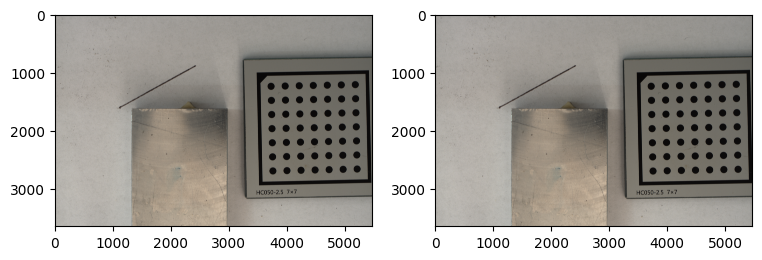

In [3]:
imgpath = 'C:\\Users\\hp\\Desktop\\mm\\3\\Image_20221230152713147.bmp' #yl
src_img = cv2.imread(imgpath, 1)
mycmm.calc_UndistortRectifyMap(src_img)
remaped_img = mycmm.img_remap(src_img)
plt.figure(figsize=(9,4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(remaped_img, cv2.COLOR_BGR2RGB))

In [4]:
#测距用的单张标定图像，该图不需要畸变矫正
#对称圆标定板上圆的行数、列数
monocular_circleSize = [7,7]
monocular_circleCellLen = 5.0 #mm，圆心距
mode = 'circle'

# 得到该标定图像中标定板上的圆心实际坐标与对应像素坐标
ret_l, world_points, pixel_points = mycmm.findCornersAndWorldPoints(singleImgPath=src_img, 
                                                chessSize=monocular_circleSize, 
                                                chessCellLen=monocular_circleCellLen, mode=mode)
A = mycmm._monocularParameters["cameraMatrix"]
distCoeff = mycmm._monocularParameters["distCoeffs"]

checked!!!!!!!!!


In [5]:
pixel_points = mycmm.points_remap(pixel_points) # 映射稀疏点，去掉畸变的影响

In [11]:
H = mycmm.findHByPnPAndZDiff(A, None, world_points, pixel_points, zLow=-3)
print(H)

[[ 2.10378919e-02 -4.55786590e-04 -7.72676882e+01]
 [ 4.67574917e-04  2.10610963e-02 -2.81490064e+01]
 [ 1.01994211e-06 -1.27745074e-08  1.00000000e+00]]


In [12]:
#zs
p0_src = np.array([[1100, 1622]], dtype=np.float32) #从原图里面量取
p1_src = np.array([[2426, 888]], dtype=np.float32)

p0_src = mycmm.points_remap(p0_src)
p1_src = mycmm.points_remap(p1_src)
p0 = np.ones(shape=(3,1), dtype=np.float32); p0[0:2,:] = p0_src.T[:,:]
p1 = np.ones(shape=(3,1), dtype=np.float32); p1[0:2,:] = p1_src.T[:,:]

################################################

#求世界坐标平面上的齐次坐标，并做归一化(一般可以不用)
pt1 = H @ p0
pt1 = pt1/pt1[-1]

pt2 = H @ p1
pt2 = pt2/pt2[-1]

length = np.sqrt(np.sum((pt1-pt2)**2)) #求解两点长度

print('H Matrix : ','\n', H, '\n')
print('source point: ', p0.reshape(-1), p1.reshape(-1))
print('dst point: ', pt1.reshape(-1), pt2.reshape(-1))
print('\nlen: ', length)

H Matrix :  
 [[ 2.10378919e-02 -4.55786590e-04 -7.72676882e+01]
 [ 4.67574917e-04  2.10610963e-02 -2.81490064e+01]
 [ 1.01994211e-06 -1.27745074e-08  1.00000000e+00]] 

source point:  [1.0936417e+03 1.6209031e+03 1.0000000e+00] [2.425445e+03 8.863283e+02 1.000000e+00]
dst point:  [-54.93841422   6.49324046   1.        ] [-26.57996075  -8.32737711   1.        ]

len:  31.997696608914687
